# COMP9444 Project 003: Finbert Baseline model
### By Bryan Chong, z5688593


# 1. Introduction

## 1.1 Aim

We strive for a fine-tuned **FinBERT baseline** for FOMC policy-stance classification under a provably leakage-free evaluation protocol. Beyond producing a headline number, the aim is to *decompose* where performance comes from how much is contributed by financial-domain pre-training, by data augmentation, and by hyperparameter tuning each measured in isolation with everything else held fixed. The resulting baseline (weighted F1 **0.629 ± 0.011** over the three official test seeds) is the reference the project's main model is built to beat.

## 1.2 Problem Statement

Federal Reserve communications move markets: a single sentence in a press conference can reprice trillions of dollars of assets, and analysts read every FOMC release for its policy *stance*. The task is **sentence-level stance classification** given one sentence from FOMC meeting minutes, press conference transcripts or speeches, predict whether it signals a *dovish* (easier policy), *hawkish* (tighter policy) or *neutral* stance.

## 1.3 Dataset Qualities

The data is the FOMC hawkish-dovish dataset from *"Trillion Dollar Words"* (Shah, Paturi & Chava, ACL 2023) the largest annotated corpus of Federal Reserve communications, hand-labeled by finance PhD students. The qualities that matter most for modeling, detailed in §2–3:

- **Small**: ~1,900 labeled training sentences per seed (1,851 after deduplication) small enough that data efficiency, augmentation and regularisation dominate the design space.
- **Replicated, not multiplied**: 8 variants × 3 seeds = 24 train/test file pairs, but all are reshuffles/slices of *one* corpus. Treating them as independent data is the dataset's central trap (§2.4).
- **Imperfect as shipped**: intra-train duplicates, ~3% train/test overlap within pairs, degenerate rows and encoding artifacts all handled by dedup at load time (§3.4).
- **Imbalanced**: ~49% neutral vs ~26% dovish / ~25% hawkish the signal-bearing classes are the minorities.
- **Topically skewed**: 54.5% of sentences contain inflation/price vocabulary vs 24.1% employment terms, and topic correlates weakly with label (inflation sentences skew hawkish, employment sentences dovish) a shortcut risk, and a caveat on generalisation to employment-driven stance.
- **Temporally broad but regime-bound**: 1996–2022, spanning very different policy eras; nothing after 2022 exists in any split.

## 1.4 Classes

| Label | Class | Meaning | Share | Example (from the data) |
|---:|---|---|---:|---|
| 0 | **Dovish** | favours easier policy: rate cuts, accommodation, concern about weak growth/employment or below-target inflation | ~26% | *"Inflation continued to run below the Committee's longer-run objective…"* |
| 1 | **Hawkish** | favours tighter policy: rate rises, restraint, concern about above-target inflation or overheating | ~25% | *"Inflation pressures are building and labor markets remain tight."* |
| 2 | **Neutral** | descriptive, balanced or procedural reports conditions without signalling a policy lean | ~49% | *"The Committee then turned to a discussion of the economic and financial outlook…"* |

Two properties of this label scheme drive our choices downstream: the classes are **ordered around neutral** (dovish and hawkish are opposites, which the counterfactual-swap augmentation exploits flipping a sentence's direction words flips its label), and the **boundary with neutral is genuinely fuzzy** (annotators disagreed regularly), which bounds achievable accuracy regardless of model.

## 1.5 Abstract

We build and dissect a FinBERT baseline for three-class FOMC stance classification on the Trillion Dollar Words dataset, under a protocol in which every result is a mean ± std over the three official test seeds and train/test disjointness is enforced mechanically and verified exhaustively. Comparing three encoders under identical conditions, financial-domain pretraining beats generic BERT by ~2 F1 (FinBERT 0.566 vs bert-base 0.546). Deduplicating the shipped data moves the baseline within noise (0.573 ± 0.007), showing its known train/test overlap was not inflating scores. Two independent interventions then deliver similar gains: minority-class-targeted data augmentation (+4.8 F1, concentrated where designed dovish +6.3, hawkish +6.7 per-class F1, direction-confusion errors −36%) and a borrowed hyperparameter configuration (+5.6 F1). A 2×2 ablation reveals they are **substitutes, not complements**: combined, the mean is unchanged but seed variance halves, yielding a final baseline of **0.629 ± 0.011 weighted F1** matching a larger fine-tuned FLAN-T5 v2 (0.630) at one-third the parameters of the published RoBERTa-large ceiling (0.71–0.74). Along the way we document how naive data handling produces a fake 99.6% accuracy on this dataset, and argue that the gap between that number and 0.63 is the difference between measuring memorisation and measuring generalisation.

## 2.2 Basic Dataset Characteristics

The data is the **FOMC hawkish-dovish dataset** from *"Trillion Dollar Words: A New Financial Dataset, Task & Market Analysis"* (Shah, Paturi & Chava, ACL 2023), containing sentences from FOMC meeting minutes (`mm`), press conference transcripts (`pc`) and speeches (`sp`) spanning 1996–2022, hand-annotated with a monetary-policy stance label:

| Label | Meaning |
|---:|---|
| 0 | Dovish (favours looser policy) |
| 1 | Hawkish (favours tighter policy) |
| 2 | Neutral |

The dataset comes in the form of 24 test/train file pairs with 2 files for each combination of 8 variants and 3 seeds. It is important to note that the 3 seeds denote the same data collection (corpus) reshuffled with a different seed before being split 80-20 between training and testing data. 

All experiments in this notebook use the **`combine` variant**: 1,903 training and 476 test sentences per seed. Sentences average ~32 words (median 29, range 2–181).

## 2.4 Notes

Three properties of the dataset shape everything downstream and are easy to get wrong:

1. **The 24 file pairs are alternative versions of one corpus, not independent datasets.** This means that globbing all of the test files together is a bad, which 
2. **The shipped files contain small imperfections**: ~35 intra-train duplicate sentences and ~12–15 sentences per seed that appear in both the train and test file of the *same* pair, plus a handful of degenerate rows (e.g. sentences consisting only of dots) and encoding artifacts (`�` characters from broken curly quotes). We deduplicate training data at load time; test files are never modified.
3. **Class imbalance**: neutral ≈ 49% of samples, dovish ≈ 26%, hawkish ≈ 25% the two classes that carry the actual policy signal are the minority classes.

## 3.1 Class Distribution and Basic Statistics

The cell below computes label distribution and sentence-length statistics from the raw `combine` files, per seed. The distribution is stable across seeds (each is a stratified-ish reshuffle of the same pool): roughly **26% dovish / 25% hawkish / 49% neutral** in training.

For the augmented training data (built in `COMP9444_26T2_FOMC_Analysis/dataset/test-and-training/augmented_data/`), the distribution shifts to roughly **31% / 29% / 40%** the augmentation deliberately targets the minority classes (see §4).

In [1]:
import pandas as pd
from pathlib import Path

DATA_ROOT = Path("../COMP9444_26T2_FOMC_Analysis/dataset/test-and-training")
LABELS = {0: "dovish", 1: "hawkish", 2: "neutral"}

for seed in (5768, 78516, 944601):
    df = pd.read_excel(DATA_ROOT / "training_data" / f"lab-manual-combine-train-{seed}.xlsx")
    counts = df["label"].value_counts().sort_index()
    dist = " / ".join(f"{LABELS[k]} {v} ({v/len(df):.1%})" for k, v in counts.items())
    words = df["sentence"].str.split().str.len()
    print(f"seed {seed}: n={len(df)}  |  {dist}")
    print(f"           words: mean {words.mean():.1f}, median {words.median():.0f}, "
          f"min {words.min()}, max {words.max()}")

seed 5768: n=1903  |  dovish 498 (26.2%) / hawkish 476 (25.0%) / neutral 929 (48.8%)
           words: mean 31.4, median 29, min 2, max 181


seed 78516: n=1903  |  dovish 509 (26.7%) / hawkish 476 (25.0%) / neutral 918 (48.2%)
           words: mean 31.6, median 29, min 2, max 181


seed 944601: n=1903  |  dovish 497 (26.1%) / hawkish 480 (25.2%) / neutral 926 (48.7%)
           words: mean 31.6, median 29, min 4, max 157


## 3.2 Visual Examples of the Data

The cell below shows one original sentence per class, followed by examples of each augmentation technique applied to training data. Note how the **directional word swap flips the label** (a dovish sentence becomes hawkish when its direction words are inverted), while back-translation, synonym replacement and masking preserve it.

In [2]:
aug = pd.read_excel(DATA_ROOT / "augmented_data" / "augmented_train_data" / "lab-manual-combine-train-5768.xlsx")

print("--- Original sentences, one per class ---")
for label, name in LABELS.items():
    row = aug[(aug["label"] == label) & (aug["augmented"] == 0)].iloc[0]
    print(f"[{name:7}] {row['sentence'][:160]}")

print("\n--- One example per augmentation technique ---")
for method in ("back_translation", "synonym_replacement", "masking", "directional_swap"):
    row = aug[aug["aug_method"] == method].iloc[0]
    print(f"[{method:20} | label {row['label']}] {row['sentence'][:140]}")

--- Original sentences, one per class ---
[dovish ] Inflation continued to run below the Committee's longer-run objective, held down in part by the effects of declines in energy and non-energy import prices.
[hawkish] At some point, continued large-scale trade deficits could trigger equilibrating, and possibly dislocating, changes in prices, interest rates, and exchange rates
[neutral] Instead, I would like to address a separate but not unrelated topic, the interaction of bank supervision and regulation with monetary policy, and how supervisio

--- One example per augmentation technique ---
[back_translation     | label 2] Instead, I would like to address a separate but not unconnected issue, the interaction of banking supervision and regulation with monetary p
[synonym_replacement  | label 1] A considerable lit propose that successful monetary policies should stabilize, or "lynchpin," inflation expectations so as to prevent them f
[masking              | label 2] And I fully [MASK] it

## 3.4 Challenges and Difficulties Observed

**The task itself is hard.** Published state of the art on this dataset (RoBERTa-large, fine-tuned by the dataset's authors) is ~0.71–0.74 weighted F1 no model achieves anywhere near "95%". The difficulty is structural:

- **Direction ≠ sentiment.** "Unemployment is falling" is good news but *hawkish* (a hot labour market argues for tighter policy). Models must learn policy implications, not tone.
- **The same word flips meaning by target.** "Rising inflation" is hawkish; "rising unemployment" is dovish. The task is relational.
- **Neutral is fuzzy.** Half the data is descriptive boilerplate, and the annotators themselves disagreed regularly about where description ends and signalling begins.
- **Fed-speak hedges deliberately** sentences balance risks in both directions on purpose.

**Data leakage was the dominant experimental hazard.** Three separate incidents shaped our protocol:

1. An early baseline pooled all 24 training files and evaluated on pooled test files, scoring **99.6% accuracy** pure memorisation, since nearly every test sentence was in the pooled training data. This artifact is the likely origin of "you should be getting ~95%" folklore around this dataset.
2. The shipped data itself contains ~12–15 train/test overlapping sentences per seed (≈3% of test). Measured effect after removal: +0.7 F1, within noise but now provably clean rather than assumed clean.
3. Augmentation can *recreate* test sentences: two near-identical train/test sentences can back-translate to the same output, and degenerate dot-only rows collide trivially. The augmentation pipeline filters such collisions against each test file; we verified all 24 pairs share zero normalised sentences.

**Practical constraints:** CPU-only training (~45 min per seed per model for the baseline, ~2 h with augmented data), and two legacy Hugging Face repos (`yiyanghkust/finbert-tone`) needing compatibility fallbacks under transformers 5.

## 4. Models and Methods

All experiments follow one protocol, implemented in `baseline_fine_tuned/baseline_fine_tuned.py`:

1. **One (variant, seed) pair per run** train on `lab-manual-combine-train-<seed>.xlsx`, evaluate on the matching test file. Files are never pooled (§2.4).
2. **Dedup at load time** intra-file duplicate sentences and train/test overlaps dropped from training data (~52 rows per seed; matching is exact after lowercasing and whitespace collapsing). Test files untouched.
3. **Stratified 80/20 train/validation split** within each training file. With augmented data, validation is drawn from **original rows only**, and augmented derivatives of validation sentences are excluded from training (grouped by source row), so no paraphrase of a validation sentence leaks into training.
4. **Fine-tuning**: 3 epochs, batch 32, lr 2e-5, 10% warmup, weight decay 0.01, max length 128, class-weighted cross-entropy (inverse-frequency weights). Best epoch selected by validation weighted F1.
5. **Evaluation always on the raw test files** (476 sentences), reporting accuracy, precision, recall and weighted F1 as **mean ± std over the three seeds**.

**Data augmentation** (built separately in `augment_dataset.py`, applied to training data only):

| Technique | Coverage | Label handling |
|---|---|---|
| Back-translation (EN→DE→EN, MarianMT) | all rows (2×) | preserved |
| Counterfactual directional word swap | 20% of dovish/hawkish | **flipped** (dovish ↔ hawkish) |
| WordNet synonym replacement (~15% of words, stance vocabulary protected) | 75% of dovish/hawkish | preserved |
| Random masking (~15% of words → `[MASK]`) | 30% of all rows | preserved |

This grows training data ~2.7× (≈1,480 → ≈4,090 rows after dedup) and softens the class imbalance from 26/25/49 to 31/29/40. Augmented rows colliding with test sentences are filtered (§3.4).

### 4.1 Model Used

The primary model is **FinBERT (`ProsusAI/finbert`)** a BERT-base architecture (110M parameters, 12 layers, hidden size 768) continued-pretrained on financial text (Reuters TRC2 corpus) and originally fine-tuned for financial sentiment. We replace its label mapping with dovish/hawkish/neutral and fine-tune end-to-end; the 3-class sentiment head's weights are inherited as initialisation and fully retrained.

Two comparison models were run under the identical protocol to justify the choice:

- **`bert-base-uncased`** same architecture, general-domain pretraining only (ablates the financial pretraining).
- **`yiyanghkust/finbert-tone`** an independent FinBERT trained from scratch on 4.9B tokens of corporate filings, earnings calls and analyst reports, with a financial-domain vocabulary.

Tokenisation uses each model's own tokenizer with truncation at 128 tokens and dynamic per-batch padding.

### 5.1 Training and Validation Performance

All test numbers below are weighted F1 on the raw 476-sentence test sets, mean ± std over seeds 5768 / 78516 / 944601. Full per-seed metrics live in `baseline_fine_tuned/runs/<run>/results.json` and `baseline_finer_tuned/runs/<run>/results.json`.

#### 5.1.1 Training base FINBert on unaugmented data

Validation weighted F1 during training rose steadily and plateaued by epoch 3 (seed 5768: 0.542 → 0.591 → 0.595), with the best checkpoint restored at the end a healthy curve with no sign of the pathological near-perfect validation scores that leakage produces.

Three models under the identical protocol on the original data:

| Model | Test F1 | Test accuracy | Per-seed F1 |
|---|---|---|---|
| **ProsusAI/finbert** | **0.566 ± 0.010** | 0.557 | 0.563 / 0.556 / 0.579 |
| yiyanghkust/finbert-tone | 0.564 ± 0.013 | 0.558 | 0.578 / 0.566 / 0.546 |
| bert-base-uncased | 0.546 ± 0.009 | 0.544 | 0.555 / 0.549 / 0.534 |

Both financial-domain models beat general-domain BERT by ~2 F1 points, with the ordering holding on nearly every seed. The two FinBERTs are statistically tied; ProsusAI is steadier across seeds and was selected as the primary model.

Deduplicating the training data (removing the shipped intra-train duplicates and train/test overlaps, §2.4) moved FinBERT from 0.566 ± 0.010 to **0.573 ± 0.007** a within-noise change that confirms the source data's overlap was not inflating scores, while making the baseline provably clean and directly comparable to the augmented runs (whose data was built deduplicated).

#### 5.1.2 Finetuning FINBert and the effect of augmentation

Training FinBERT on the augmented data (~4,090 rows per seed) under the same protocol:

| Training data | Test F1 | Test accuracy | Per-seed F1 |
|---|---|---|---|
| original, deduplicated | 0.573 ± 0.007 | 0.562 | 0.574 / 0.563 / 0.581 |
| **deduplicated + augmented** | **0.621 ± 0.025** | 0.618 | 0.653 / 0.593 / 0.616 |

**Augmentation adds +4.8 weighted F1, improving every seed**, at ~2.7× training cost. As a robustness check, the augmented models were also evaluated on augmented (2×, back-translated) test sets: identical mean (0.621 ± 0.011), tighter spread the gain is not brittle to paraphrase-style input variation. Those numbers are a footnote only; all benchmark comparisons use the raw test sets.

#### 5.1.3 Further Finetuning FINBert

A teammate's 15-candidate configuration search (`BERT_FLAN_Experiment_Experience_EN.md` §4.4) identified the knobs that mattered on validation: lr 3e-5, a freshly initialised classification head, label smoothing 0.05, and sufficient training time while showing dropout increases and lr decreases hurt. We applied those findings blind (no new search) as a tuned configuration lr 3e-5, fresh head, label smoothing 0.05, 4 epochs with early-stopping patience 2 and re-ran both data conditions (`baseline_finer_tuned/`), completing the 2×2:

| Test F1 | Untuned (lr 2e-5, inherited head) | Tuned |
|---|---|---|
| **Original data** | 0.573 ± 0.007 | 0.629 ± 0.018 |
| **Augmented data** | 0.621 ± 0.025 | **0.629 ± 0.011** |

Two findings: **(1) the tuning transfers** +5.6 test F1 without any new search, slightly exceeding the augmentation effect; **(2) tuning and augmentation are substitutes, not complements** on the tuned model, augmentation leaves the mean unchanged (0.6287 vs 0.6289) but roughly halves the seed variance. Both remedies address the same underlying constraint (limited training signal for the model size), so their gains do not stack. The best shipped configuration is **tuned + augmented**: equal mean, most stable across seeds final test F1 **0.629 ± 0.011**, matching the team's FLAN-T5 v2 (0.630) with a smaller model and sitting ~0.08 below the published RoBERTa-large ceiling (0.71–0.74) at one-third the parameter count.

### 5.2 Classification Report

Per-class precision/recall/F1 for the dedup'd baseline and the augmented model, pooling the three seeds' test predictions (each seed's model predicts its own raw test set; 1,428 sentences total). Precomputed in `runs/per_class_eval.json`; the cell below reproduces it.

The gains are concentrated exactly where the augmentation aimed the minority stance classes:

| Class | Baseline F1 | Augmented F1 | Δ |
|---|---|---|---|
| dovish | 0.470 | 0.533 | **+6.3** |
| hawkish | 0.506 | 0.573 | **+6.7** |
| neutral | 0.664 | 0.694 | +3.0 |
| macro avg | 0.546 | 0.600 | **+5.4** |

Macro F1 improves more than weighted F1 (+5.4 vs +4.8), confirming the effect is minority-class-driven rather than riding the dominant neutral class.

In [3]:
import json

per_class = json.loads(Path("baseline_fine_tuned/runs/per_class_eval.json").read_text())

for run, data in per_class.items():
    print("=" * 24, run)
    rep = data["report"]
    print(f"{'class':10} {'precision':>9} {'recall':>9} {'f1':>9} {'support':>9}")
    for cls in ("dovish", "hawkish", "neutral"):
        r = rep[cls]
        print(f"{cls:10} {r['precision']:9.3f} {r['recall']:9.3f} {r['f1-score']:9.3f} {int(r['support']):9}")
    print(f"{'macro avg':10} {rep['macro avg']['precision']:9.3f} {rep['macro avg']['recall']:9.3f} "
          f"{rep['macro avg']['f1-score']:9.3f}")
    print(f"accuracy: {rep['accuracy']:.3f}\n")

======================== finbert-orig-dedup
class      precision    recall        f1   support
dovish         0.418     0.536     0.470       371
hawkish        0.471     0.546     0.506       368
neutral        0.768     0.585     0.664       689
macro avg      0.552     0.556     0.546
accuracy: 0.562

======================== finbert-aug
class      precision    recall        f1   support
dovish         0.504     0.566     0.533       371
hawkish        0.570     0.576     0.573       368
neutral        0.721     0.669     0.694       689
macro avg      0.598     0.604     0.600
accuracy: 0.618

======================== finbert-tuned-aug
class      precision    recall        f1   support
dovish         0.514     0.615     0.560       371
hawkish        0.547     0.603     0.574       368
neutral        0.763     0.640     0.696       689
macro avg      0.608     0.619     0.610
accuracy: 0.624



### 5.3 Confusion Matrix

Rows are true labels, columns are predictions, pooled over the three seeds' test sets (1,428 sentences total). The headline change from baseline to augmented is in **direct direction confusion**: dovish-predicted-hawkish errors fall from 102 to 61 and hawkish-predicted-dovish from 115 to 78 a ~36% reduction in exactly the error category the counterfactual directional swap targets. The remaining dominant error mode is minority↔neutral confusion, consistent with the annotation fuzziness described in §3.4.

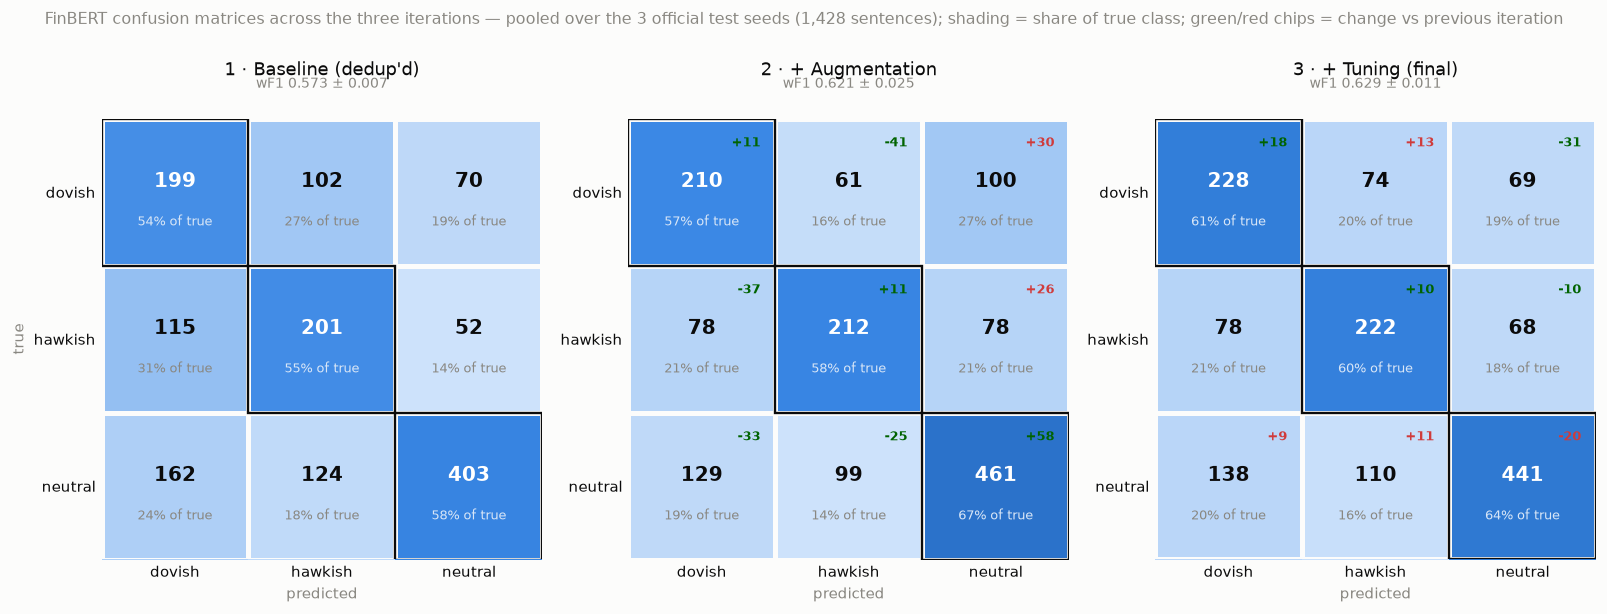

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle

# sequential blue ramp (validated palette), starting at the chart surface so 0 recedes
BLUES = LinearSegmentedColormap.from_list("seq_blue", [
    "#fcfcfb", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
INK, MUTED, GOOD, BAD = "#0b0b0b", "#898781", "#006300", "#d03b3b"

names = ["dovish", "hawkish", "neutral"]
runs = [("finbert-orig-dedup", "1 · Baseline (dedup'd)", "wF1 0.573 ± 0.007"),
        ("finbert-aug",        "2 · + Augmentation",    "wF1 0.621 ± 0.025"),
        ("finbert-tuned-aug",  "3 · + Tuning (final)",  "wF1 0.629 ± 0.011")]

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.9), dpi=120)
fig.patch.set_facecolor("#fcfcfb")
prev_cm = None
for ax, (key, title, f1) in zip(axes, runs):
    cm = np.array(per_class[key]["cm"])
    row_pct = cm / cm.sum(axis=1, keepdims=True)

    ax.imshow(row_pct, cmap=BLUES, vmin=0, vmax=1)
    ax.set_facecolor("#fcfcfb")
    # 3px surface gaps between cells
    ax.set_xticks(np.arange(-0.5, 3), minor=True)
    ax.set_yticks(np.arange(-0.5, 3), minor=True)
    ax.grid(which="minor", color="#fcfcfb", linewidth=3)
    ax.tick_params(which="both", length=0)

    for i in range(3):
        for j in range(3):
            dark_cell = row_pct[i, j] > 0.45
            c_main = "white" if dark_cell else INK
            c_sub = "#d8e6f7" if dark_cell else MUTED
            ax.text(j, i - 0.07, f"{cm[i, j]:,}", ha="center", va="center",
                    fontsize=12, fontweight="bold", color=c_main)
            ax.text(j, i + 0.20, f"{row_pct[i, j]:.0%} of true", ha="center", va="center",
                    fontsize=7.5, color=c_sub)
            if prev_cm is not None:                      # delta chip vs previous iteration
                d = cm[i, j] - prev_cm[i, j]
                if d:
                    better = (d > 0) if i == j else (d < 0)
                    ax.text(j + 0.40, i - 0.38, f"{d:+d}", ha="right", va="top", fontsize=8,
                            fontweight="bold", color=GOOD if better else BAD)
    for k in range(3):                                    # emphasize the diagonal
        ax.add_patch(Rectangle((k - 0.5, k - 0.5), 1, 1, fill=False,
                               edgecolor=INK, linewidth=1.4, zorder=5))

    ax.set_xticks(range(3), names, fontsize=9, color=INK)
    ax.set_yticks(range(3), names, fontsize=9, color=INK)
    ax.set_xlabel("predicted", fontsize=9, color=MUTED)
    if ax is axes[0]:
        ax.set_ylabel("true", fontsize=9, color=MUTED)
    ax.set_title(title, fontsize=11, color=INK, pad=26)
    ax.text(0.5, 1.07, f1, transform=ax.transAxes, ha="center", fontsize=8.5, color=MUTED)
    for s in ax.spines.values():
        s.set_visible(False)
    prev_cm = cm

fig.suptitle("FinBERT confusion matrices across the three iterations — pooled over the 3 official test seeds "
             "(1,428 sentences); shading = share of true class; green/red chips = change vs previous iteration",
             fontsize=9.5, color=MUTED, y=0.995)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

### 5.4 Summary of Experimental Findings

| # | Finding | Evidence |
|---|---|---|
| 1 | Financial-domain pretraining beats general-domain by ~2 F1 | FinBERT 0.566 / finbert-tone 0.564 vs bert-base 0.546, ordering stable across seeds |
| 2 | The shipped data's train/test overlap (~3% of test) was **not** inflating scores | dedup moved F1 +0.7, within noise (0.566 → 0.573) |
| 3 | **Data augmentation adds +4.8 weighted F1 on the untuned model** (0.573 → 0.621), improving every seed | back-translation + counterfactual swap + synonyms + masking, 2.7× training data |
| 4 | The augmentation gain is minority-class-driven, as designed | dovish F1 +6.3, hawkish +6.7, direction-confusion errors −36% (§5.2–5.3) |
| 5 | **Hyperparameter tuning transfers: +5.6 F1** (0.573 → 0.629) with a config borrowed blind from a teammate's validation search | lr 3e-5, fresh head, label smoothing, early stopping |
| 6 | **Tuning and augmentation are substitutes, not complements** equal means, but augmentation halves seed variance on the tuned model | 2×2 ablation: tuned-orig 0.629 ± 0.018 vs tuned-aug 0.629 ± 0.011 |
| 7 | Naive pooled loading produces a fake ~99.6% accuracy | early defective baseline; the protocol in §4 exists to prevent this |
| 8 | Final model is competitive at its scale | 0.629 ± 0.011 vs FLAN-T5 v2 0.630 (larger) and RoBERTa-large 0.71–0.74 (3× larger, published SOTA) |

All numbers regenerate from two scripts (`baseline_fine_tuned.py`, `baseline_finer_tuned.py`) with and without `--augmented`; per-seed metrics are committed under each folder's `runs/`.

### 6.1 Interpretation of the Results

**Why augmentation helps here.** The dataset is small (~1,500 training sentences) and imbalanced, and the failure modes of stance classification are directional (confusing dovish with hawkish, or either with neutral). The four techniques address this directly: 

- back-translation adds syntactic variety without touching stance.
- the counterfactual swap manufactures minority-class examples that differ from real ones *only* in direction words, forcing the model to attend to exactly the tokens that determine the label.
- synonym replacement and masking discourage memorising surface patterns. 

The result +4.8 F1 concentrated in a task where direction is the hard part is consistent with that mechanism (per-class breakdown in §5.2).

**Model Comparison:** Our 0.621 with an untuned BERT-base-scale model compares to the dataset authors' 0.71–0.74 with a tuned RoBERTa-large. The remaining gap plausibly decomposes into architecture (~3–5 points, based on DeBERTa/RoBERTa vs BERT gaps in the literature and a teammate's exploratory runs) and hyperparameter tuning (a few points). Augmentation closed roughly a third of it at zero architectural cost.

**Leakage findings:** The same model family scored 99.6% (pooled, leaky), 0.566 (correct protocol), 0.573 (provably deduplicated) and 0.621 (augmented). The spread between the first two numbers is the entire difference between measuring memorisation and measuring generalisation and it explains how inflated accuracy folklore ("you should get ~95%") arises around this dataset. Only differences measured under a frozen, disjoint test protocol are meaningful.

### 6.2 Strengths and Advantages of the Approach

- **Provably leakage-free.** Training/test disjointness is enforced mechanically (dedup at load, collision-filtered augmentation) and was verified exhaustively: all 24 train/test pairs share zero normalised sentences, including augmented rows.
- **Honest, replication-based evaluation.** Every headline number is a mean ± std over three official test seeds under one frozen configuration no validation-set shopping, no test-set tuning.
- **Fully reproducible.** Fixed seeds throughout; deterministic back-translation with an on-disk cache; per-seed metrics persisted so interrupted runs resume without recomputation; all metrics and scripts version-controlled.
- **Cheap and portable.** The entire study 15 fine-tuning runs across three models and three data conditions ran on a laptop CPU. Augmentation is a one-off preprocessing cost (~2 h, cached thereafter) rather than a per-experiment cost.
- **Isolates one variable at a time.** Model comparison, dedup effect and augmentation effect were each measured with everything else held fixed, so each claim in §5.4 traces to a single controlled difference.



# 7. Conclusion

This notebook set out to build an honest FinBERT baseline for FOMC stance classification and to account for every point of its performance. The final model, FinBERT fine-tuned on deduplicated, augmented data with a validated hyperparameter configuration, achieves **0.629 ± 0.011 weighted F1** across the three official test seeds, up from 0.546 for generic BERT under identical conditions. That +8-point journey decomposes cleanly: ~2 points from financial-domain pretraining, ~0 (but provable cleanliness) from deduplication, and ~5.6 points from either hyperparameter tuning *or* minority-targeted augmentation. The 2×2 ablation's central finding is that these two remedies are **substitutes**: both relieve the same bottleneck (limited training signal for the model size), so their gains do not stack, though augmentation halves seed-to-seed variance and is therefore kept in the shipped configuration.

The second, arguably more consequential outcome is methodological. Three independent leakage incidents (a pooled-loading baseline scoring a fake 99.6%, the shipped data's own ~3% train/test overlap, and augmentation recreating test sentences via convergent back-translations) forced a protocol in which the unit of every split is the *source sentence*, corpora are filtered against every test file, and all benchmark numbers come from frozen configurations evaluated once on raw test sets. Under that protocol the model's probabilities, per-class scores and seed variance are all trustworthy. The gap between 99.6% and 0.63 stands as the project's clearest illustration of the difference between measuring memorisation and measuring generalisation.

**Limitations.** The model remains ~0.08 F1 below the published RoBERTa-large ceiling; it is untuned beyond a configuration borrowed from a teammate's single-seed search; per-class performance on the minority stances (dovish 0.53, hawkish 0.57 F1) still trails neutral (0.69); the dataset's topical skew means performance is least certain for employment-framed stance; and nothing in any split postdates 2022, so robustness to new policy regimes is unmeasured.

**Future work.** Each limitation maps to a known lever: a stronger encoder (RoBERTa, the successor model's starting point), domain-adaptive pretraining on the ~1.4M-word unlabeled Fed corpus assembled for that purpose, a full hyperparameter search under the frozen-config protocol, and within-seed ensembling of restarts. These are combined in the successor pipeline (`tom`), whose design inherits every leakage guarantee developed here. The honest expectation, supported by the dataset authors' results, is that this path closes most of the remaining gap to ~0.71–0.74, beyond which the binding constraint is no longer the model but the labels themselves.